In [1]:
!pip install selenium==4.6
!pip install yt-dlp


[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from selenium import webdriver
from selenium.webdriver.firefox.service import Service
from selenium.webdriver.common.by import By
import requests
import os
import csv
import time
import hashlib

# Ruta donde descomprimiste geckodriver.exe
gecko_path = "C:/Program Files/WebDrivers/geckodriver.exe"

options = webdriver.FirefoxOptions()
options.add_argument("--start-maximized")

driver = webdriver.Firefox(service=Service(gecko_path), options=options)

driver.get("https://www.facebook.com")
# driver.get("https://x.com")
time.sleep(10)

input("Inicia sesión manualmente y presiona ENTER aquí...")

''

In [3]:
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By
from selenium.common.exceptions import TimeoutException
import time

def fechaFilter(year):
    wait = WebDriverWait(driver, 15)

    try:
        publicaciones_btn = wait.until(EC.element_to_be_clickable((By.XPATH, "//span[text()='Publicaciones' or text()='Posts']")))
        publicaciones_btn.click()
        print("✅ Se hizo clic en Publicaciones")
        time.sleep(3)
    except Exception as e:
        print(f"❌ No se encontró la sección Publicaciones: {e}")

    try:
        filtros_btn = wait.until(EC.element_to_be_clickable((By.XPATH, "//span[contains(text(), 'Filtros') or contains(text(), 'Filters')]")))
        filtros_btn.click()
        print("✅ Se abrió el menú de filtros")
        time.sleep(2)

        fecha_btn = wait.until(EC.element_to_be_clickable((By.XPATH, "//span[contains(text(), 'Fecha de publicación') or contains(text(), 'Date posted')]")))
        fecha_btn.click()
        time.sleep(2)

        # Usamos presence_of_element para asegurarnos de que está en el DOM
        year_xpath = f"//span[text()='{year}']"
        year_element = wait.until(EC.presence_of_element_located((By.XPATH, year_xpath)))
        driver.execute_script("arguments[0].click();", year_element)
        print(f"✅ Filtro por año aplicado con JS click: {year}")
        time.sleep(3)

    except TimeoutException:
        print(f"⚠️ No se encontró el filtro de año '{year}' en el tiempo de espera")
    except Exception as e:
        print(f"⚠️ Error al aplicar filtro de año {year}: {e}")


In [4]:
from selenium.webdriver.common.keys import Keys

def fechaFilterTwitterX(year):
    wait = WebDriverWait(driver, 20)

    try:
        # Esperar que cargue el campo de búsqueda
        search_inputs = wait.until(EC.presence_of_all_elements_located((By.XPATH, "//input[contains(@placeholder, 'Buscar') or contains(@placeholder, 'Search')]")))

        if not search_inputs:
            raise Exception("No se encontró el campo de búsqueda")

        search_input = search_inputs[0]
        time.sleep(1)

        # Extraer el query actual desde la URL si el input está vacío
        current_query = search_input.get_attribute("value")
        if not current_query:
            current_query = driver.current_url.split("q=")[-1].split("&")[0]
            current_query = current_query.replace("%20", " ")

        start_date = f"{year}-01-01"
        end_date = f"{year}-12-31"
        new_query = f"{current_query} since:{start_date} until:{end_date}"

        # Borrar y escribir la nueva búsqueda
        search_input.clear()
        search_input.send_keys(new_query)
        search_input.send_keys(Keys.RETURN)

        print(f"✅ Se aplicó el filtro para el año {year}")
        time.sleep(5)

    except Exception as e:
        print(f"❌ Error al aplicar el filtro de fecha en Twitter/X: {e}")




In [2]:
hashtag = "incendio forestal"
location_hashtag = "Madre de Dios peru"
year = "2023"  
class_label = "incêndio florestal"
max_images = 40
# inundações

# --- URL de búsqueda en Facebook ---
search_url = f"https://www.facebook.com/search/top?q={hashtag}%20{location_hashtag}"

# --- URL de búsqueda en X ---
# search_url = f"https://x.com/search?q={hashtag}%20{location_hashtag}"

# --- Inicializar navegador ---
driver.get(search_url)
fechaFilter(year)
# fechaFilterTwitterX(year)
time.sleep(10)


# --- Preparar carpetas y rutas ---
folder_name = class_label.lower().replace(" ", "_")
img_base_path = os.path.join("dataset", folder_name)
os.makedirs(img_base_path, exist_ok=True)
csv_path = os.path.join("dataset", "dataset.csv")


# --- Leer imágenes ya descargadas ---
descargados = set()
if os.path.exists(csv_path) and os.path.getsize(csv_path) > 0:
    with open(csv_path, mode='r', encoding='utf-8', errors='ignore') as csv_file:
        reader = csv.DictReader(csv_file)
        for row in reader:
            descargados.add(row["img_path"])

# --- Abrir CSV para escritura ---
csv_existe = os.path.exists(csv_path)
csv_file = open(csv_path, mode='a', newline='', encoding='utf-8')
csv_writer = csv.writer(csv_file)
if not csv_existe:
    csv_writer.writerow(["class_label", "img_path", "post_text"])

# --- Scroll para cargar más contenido ---
for _ in range(5):
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(5)

# ver_mais_buttons = driver.find_elements(By.XPATH, '//div[contains(text(), "Ver más")]')
ver_mais_buttons = driver.find_elements(By.XPATH, '//div[contains(text(), "Ver más") or contains(text(), "Show more")]')

for btn in ver_mais_buttons:
    try:
        driver.execute_script("arguments[0].click();", btn)
        time.sleep(0.3)
    except Exception as e:
        print(f"[!] No se pudo hacer clic en 'Ver más': {e}")

# --- Extraer posts e imágenes ---
# Facebook
posts = driver.find_elements(By.XPATH, '//div[@data-ad-preview="message"]')
imagenes = driver.find_elements(By.XPATH, '//img[contains(@src, "scontent")]')

# X
# posts =  driver.find_elements(By.XPATH, '//div[@data-testid="tweetText"]')
# imagenes = driver.find_elements(By.XPATH, '//img[contains(@src, "twimg.com/media")]')

# Instagram


# --- Descargar imágenes con texto ---
guardadas = 0
for i in range(len(posts)):
    if guardadas >= max_images:
        break

    texto = posts[i].text.strip()
    img_url = imagenes[i].get_attribute("src") if i < len(imagenes) else None

    if texto and img_url:
        img_hash = hashlib.md5(img_url.encode()).hexdigest()
        img_path = os.path.join(img_base_path, f"{img_hash}.jpg")

        if img_path not in descargados:
            try:
                # img_data = requests.get(img_url).content
                headers = {"User-Agent": "Mozilla/5.0"}
                img_data = requests.get(img_url, headers=headers).content
                with open(img_path, 'wb') as handler:
                    handler.write(img_data)

                texto_limpio = texto.replace("\n", " ")
                csv_writer.writerow([class_label, img_path, texto_limpio])
                descargados.add(img_path)
                guardadas += 1
                print(f"[{guardadas}/{max_images}] Imagen guardada: {img_path}")
            except Exception as e:  
                print(f"[X] Error al descargar imagen: {e}")

# --- Cierre ---
csv_file.close()
# driver.quit()
print("✅ Dataset generado en:", img_base_path)


NameError: name 'driver' is not defined

In [3]:
import os
import csv

img_base_path = os.path.join("dataset", "huaico")

csv_path = 'dataset\dataset.csv'

# --- Leer CSV y filtrar registros válidos ---
temp_rows = []
with open(csv_path, mode='r', encoding='utf-8') as file:
    reader = csv.DictReader(file)
    for row in reader:
        img_path = row["img_path"]
        if os.path.exists(img_path):  # Verifica si el archivo existe
            temp_rows.append(row)
        else:
            print(f"[!] Imagen no encontrada y será eliminada del CSV: {img_path}")

# --- Reescribir CSV sin las filas eliminadas ---
with open(csv_path, mode='w', newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=["class_label", "img_path", "post_text"])
    writer.writeheader()
    writer.writerows(temp_rows)

print("✅ Revisión completa. CSV actualizado.")

[!] Imagen no encontrada y será eliminada del CSV: dataset\enchente\c838ffd0f02fc3b22d8ef526b5c34f24.jpg
[!] Imagen no encontrada y será eliminada del CSV: dataset\enchente\2eb832fe75c8bc68fc3ed7481e8db67a.jpg
[!] Imagen no encontrada y será eliminada del CSV: dataset\huaico\f393a007ff53339c903b4aae56685a53.jpg
[!] Imagen no encontrada y será eliminada del CSV: dataset\huaico\eb5e9269101b135c8dafac43b15786d3.jpg
[!] Imagen no encontrada y será eliminada del CSV: dataset\huaico\a07ab1b656b5df0477fafbbe9c25067a.jpg
[!] Imagen no encontrada y será eliminada del CSV: dataset\huaico\cbca7e001759dc32b4e013ff4bb5ad90.jpg
[!] Imagen no encontrada y será eliminada del CSV: dataset\huaico\a4d9dd259952d5da59d3d2cb3bdfc713.jpg
[!] Imagen no encontrada y será eliminada del CSV: dataset\huaico\b437cf6aabd79c2d625ebd687733a547.jpg
[!] Imagen no encontrada y será eliminada del CSV: dataset\huaico\58181546ffe7d7bac3408e927eaabf6b.jpg
[!] Imagen no encontrada y será eliminada del CSV: dataset\huaico\0fd

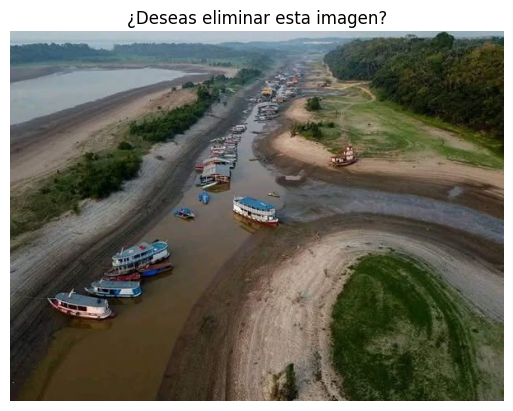


Texto:
#Brasil 𝘼𝙇𝘼𝙍𝙈𝘼𝙉𝙏𝙀 𝙀𝙡 𝙍𝙄́𝙊 𝘼𝙈𝘼𝙕𝙊𝙉𝘼𝙎 𝙎𝙀 𝙎𝙀𝘾𝘼  El río Amazonas atraviesa una sequía sin precedentes, con su cauce reduciéndose drásticamente en las regiones del norte de Brasil y Perú. Este descenso, nunca antes visto, está poniendo en peligro a especies nativas como los delfines rosados, nutrias y anacondas. Los efectos combinados del fenómeno de El Niño y el cambio climático son los principales responsables. Las comunidades ribereñas, cuya economía depende de la pesca, han reportado severas pérdidas debido a la escasez de agua y la disminución de peces, afectando su sustento diario.



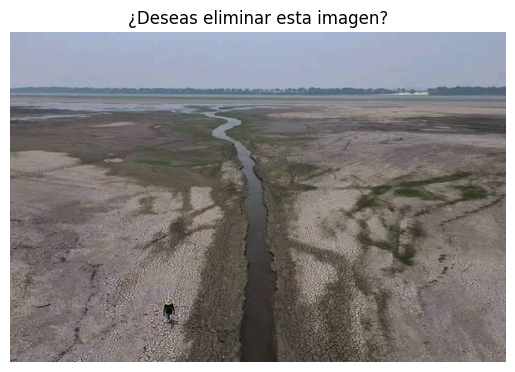


Texto:
Tefé, Amazonas, Brasil.  Seca extrema



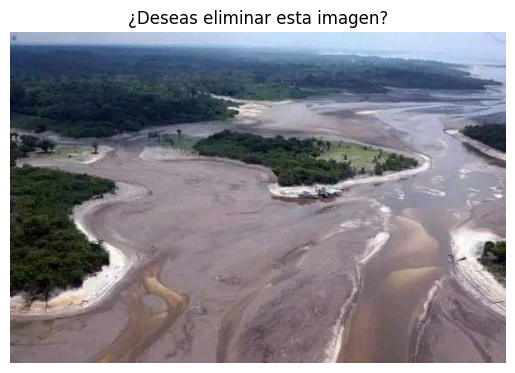


Texto:
Tefé, Amazonas - Brasil.  Seca extrema.



In [ ]:
import os
import csv
from PIL import Image
import matplotlib.pyplot as plt

csv_path = 'dataset\dataset.csv'  # <-- cambia esta ruta
img_base_path = os.path.join("dataset", "seca")
temp_rows = []

# Leer CSV original
with open(csv_path, mode='r', encoding='utf-8') as file:

    reader = csv.DictReader(file)
    for row in reader:

        img_path = row["img_path"]
        texto = row["post_text"]

        if not img_path.startswith(img_base_path):
            continue 

        if not os.path.exists(img_path):
            print(f"[!] Imagen no encontrada: {img_path}")
            continue
  
        # Mostrar imagen
        with Image.open(img_path) as img:
            plt.imshow(img)
            plt.axis('off')
            plt.title("¿Deseas eliminar esta imagen?")
            plt.show()

        # Mostrar texto
        print(f"\nTexto:\n{texto}\n")

        # Preguntar si desea conservarla
        opcion = input("¿Eliminar esta imagen? (s = sí / enter = no): ").strip().lower()
        if opcion == 's':
            os.remove(img_path)
            print(f"[✓] Imagen eliminada: {img_path}\n")
        else:
            temp_rows.append(row)  # conservar esta fila

# # Reescribir CSV sin las filas eliminadas
# with open(csv_path, mode='w', newline='', encoding='utf-8') as file:
#     writer = csv.DictWriter(file, fieldnames=["class_label", "img_path", "post_text"])
#     writer.writeheader()
#     writer.writerows(temp_rows)

# print("✅ Revisión completa. CSV actualizado.")


In [ ]:



# hashtag = "inundações ruas"
# location_hashtag = "Brasil"
# search_url = f"https://www.facebook.com/search/top?q={hashtag}%20{location_hashtag}"


# class_label = "chuva_forte"
# max_images = 30

# driver.get(search_url)
# time.sleep(10)

# # Crear carpetas
# folder_name = hashtag.lower().replace(" ", "_")
# base_path = os.path.join("dataset", folder_name)
# img_base_path = os.path.join(base_path, "img")
# os.makedirs(img_base_path, exist_ok=True)

# # Crear CSV
# csv_path = os.path.join(base_path, "dataset.csv")
# csv_file = open(csv_path, mode='w', newline='', encoding='utf-8')
# csv_writer = csv.writer(csv_file)
# csv_writer.writerow(["label", "img_path", "post_text"])


# # Leer URLs ya guardadas (si existen)
# descargados = set()
# if os.path.exists(csv_path):
#     with open(csv_path, mode='r', encoding='utf-8') as csv_file:
#         reader = csv.DictReader(csv_file)
#         for row in reader:
#             descargados.add(row["img_path"])  # usamos img_path para evitar duplicados


In [ ]:
# with open(csv_path, mode='a', newline='', encoding='utf-8') as csv_file:
#     csv_writer = csv.writer(csv_file)
    
#     # Escribir encabezado solo si el archivo estaba vacío
#     if os.stat(csv_path).st_size == 0:
#         csv_writer.writerow(["label", "img_path", "post_text"])

#     guardadas = 0
#     while guardadas < max_images:
#         posts = driver.find_elements(By.XPATH, '//div[@data-ad-preview="message"]')
#         imagenes = driver.find_elements(By.XPATH, '//img[contains(@src, "scontent")]')

#         for i in range(min(len(posts), len(imagenes))):
#             if guardadas >= max_images:
#                 break

#             texto = posts[i].text.strip()
#             img_url = imagenes[i].get_attribute("src")

#             img_path = os.path.join(img_base_path, f"img_{hash(img_url)}.jpg")  # nombre único

#             if texto and img_url and img_path not in descargados:
#                 try:
#                     img_data = requests.get(img_url).content
#                     with open(img_path, 'wb') as handler:
#                         handler.write(img_data)

#                     texto_limpio = texto.replace("\n", " ")
#                     csv_writer.writerow([class_label, img_path, texto_limpio])

#                     descargados.add(img_path)
#                     guardadas += 1
#                     print(f"[{guardadas}/{max_images}] Imagen guardada: {img_path}")
#                 except Exception as e:
#                     print(f"[X] Error al descargar imagen: {e}")

#         if guardadas < max_images:
#             driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
#             time.sleep(5)

# # Finalizar
# driver.quit()
# print("✅ Dataset actualizado en:", base_path)